In [ ]:
# 04 - Visualisations and Insights

This notebook presents the final visual outputs from the market value modelling stage.

The aim is to communicate:
- model performance
- predicted vs actual player value
- undervalued player opportunities
- key drivers of market value
- limitations of the analysis

In [21]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option("display.max_columns", None)

In [22]:
df = pd.read_csv("../data/modelled_players_all.csv")
df_filtered = pd.read_csv("../data/modelled_players_filtered.csv")
top_gap = pd.read_csv("../data/top_undervalued_players_gap.csv")
top_pct = pd.read_csv("../data/top_undervalued_players_pct.csv")

print("All players:", df.shape)
print("Filtered players:", df_filtered.shape)
print("Top gap:", top_gap.shape)
print("Top pct:", top_pct.shape)

All players: (1761, 151)
Filtered players: (1645, 151)
Top gap: (20, 151)
Top pct: (20, 151)


In [23]:
value_cols = [
    "actual_value",
    "predicted_value",
    "undervaluation_gap"
]

for data in [df, df_filtered, top_gap, top_pct]:
    for col in value_cols:
        if col in data.columns:
            data[col] = pd.to_numeric(data[col], errors="coerce")

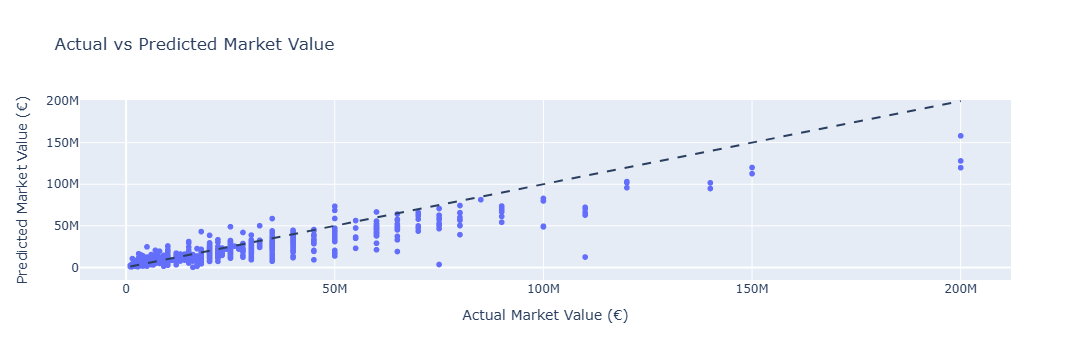

In [24]:
fig = px.scatter(
    df_filtered,
    x="actual_value",
    y="predicted_value",
    hover_name="Player",
    title="Actual vs Predicted Market Value",
    labels={
        "actual_value": "Actual Market Value (€)",
        "predicted_value": "Predicted Market Value (€)"
    }
)

fig.add_shape(
    type="line",
    x0=df_filtered["actual_value"].min(),
    y0=df_filtered["actual_value"].min(),
    x1=df_filtered["actual_value"].max(),
    y1=df_filtered["actual_value"].max(),
    line=dict(dash="dash")
)

fig.show()

In [25]:
## Insight

Players above the diagonal line have predicted values greater than their current market value, suggesting they may be undervalued based on their statistical profile.

SyntaxError: invalid syntax (3349929996.py, line 3)

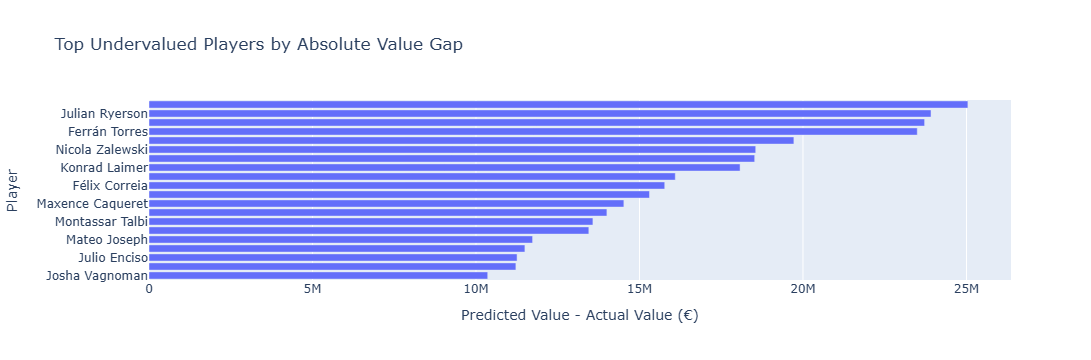

In [26]:
plot_df = top_gap.sort_values("undervaluation_gap", ascending=True)

fig = px.bar(
    plot_df,
    x="undervaluation_gap",
    y="Player",
    orientation="h",
    hover_data=["actual_value", "predicted_value"],
    title="Top Undervalued Players by Absolute Value Gap",
    labels={
        "undervaluation_gap": "Predicted Value - Actual Value (€)",
        "Player": "Player"
    }
)

fig.show()

In [ ]:
## Insight

The absolute undervaluation gap highlights players whose predicted value is substantially higher than their current valuation. This is most useful for identifying larger potential transfer-market inefficiencies.

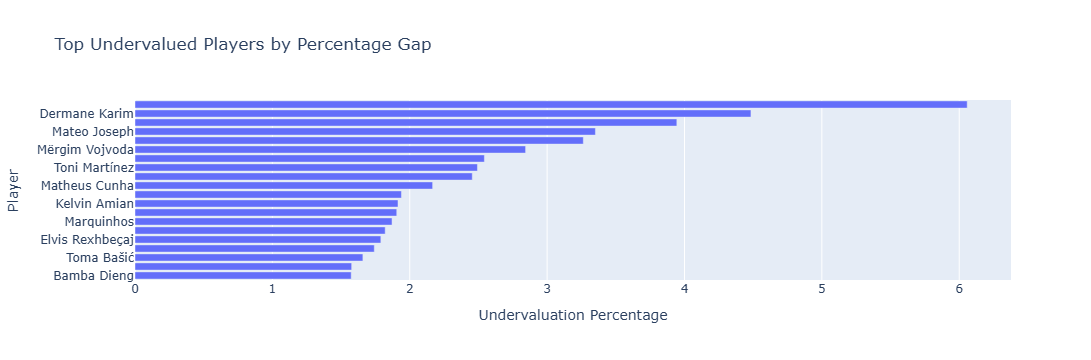

In [27]:
plot_df = top_pct.sort_values("undervaluation_pct", ascending=True)

fig = px.bar(
    plot_df,
    x="undervaluation_pct",
    y="Player",
    orientation="h",
    hover_data=["actual_value", "predicted_value", "undervaluation_gap"],
    title="Top Undervalued Players by Percentage Gap",
    labels={
        "undervaluation_pct": "Undervaluation Percentage",
        "Player": "Player"
    }
)

fig.show()

In [ ]:
## Insight

Percentage undervaluation helps identify players whose predicted value is high relative to their current market value. This is useful for spotting lower-cost opportunities rather than only highlighting already expensive players.

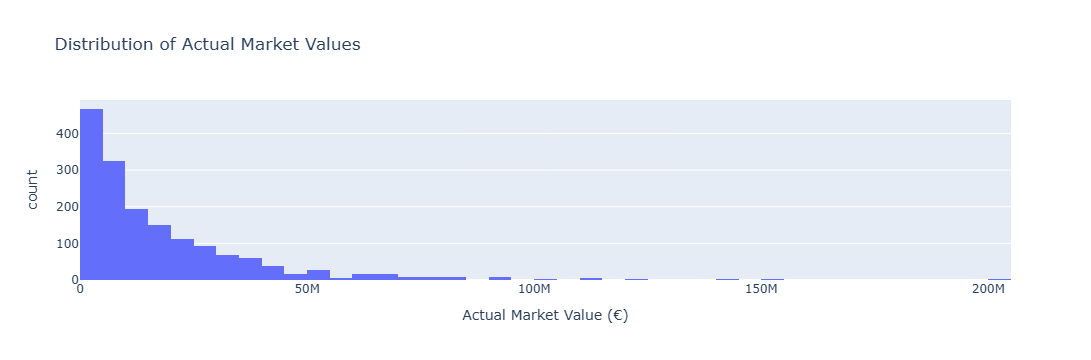

In [28]:
fig = px.histogram(
    df_filtered,
    x="actual_value",
    nbins=50,
    title="Distribution of Actual Market Values",
    labels={"actual_value": "Actual Market Value (€)"}
)

fig.show()

In [ ]:
## Insight

Market value is heavily skewed, with a small number of elite players valued far above the majority. This supports the decision to use a log transformation during modelling.

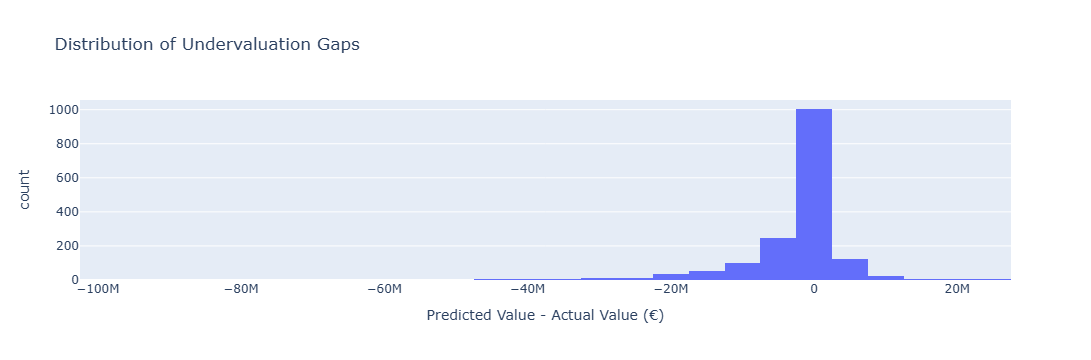

In [29]:
fig = px.histogram(
    df_filtered,
    x="undervaluation_gap",
    nbins=50,
    title="Distribution of Undervaluation Gaps",
    labels={"undervaluation_gap": "Predicted Value - Actual Value (€)"}
)

fig.show()

In [ ]:
## Insight

The gap distribution shows how far predicted valuations differ from actual market values. Positive values suggest possible undervaluation, while negative values suggest possible overvaluation.

,position_group,avg_actual_value,avg_predicted_value,avg_undervaluation_gap,player_count
0,DEF,1.465879e+07,1.301780e+07,-1.640996e+06,597
1,FWD,2.093054e+07,1.729061e+07,-3.639926e+06,167
2,GK,1.062174e+07,9.730315e+06,-8.914244e+05,115
3,MID,1.926945e+07,1.610239e+07,-3.167064e+06,766


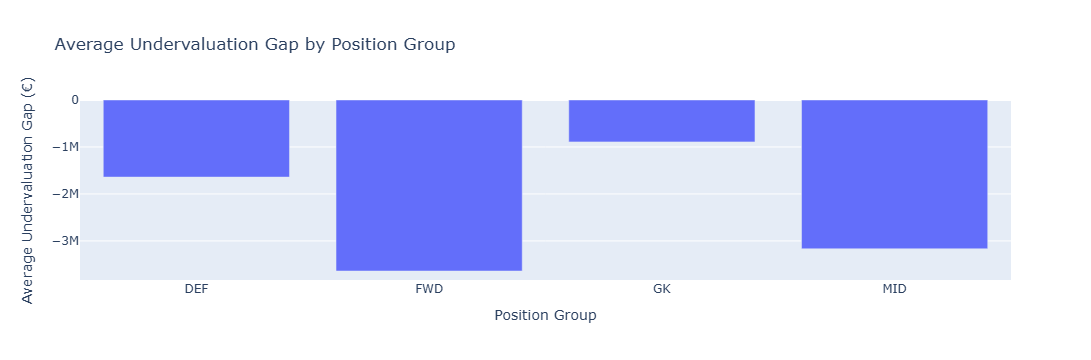

In [30]:
if "position_group" in df_filtered.columns:
    position_summary = (
        df_filtered
        .groupby("position_group")
        .agg(
            avg_actual_value=("actual_value", "mean"),
            avg_predicted_value=("predicted_value", "mean"),
            avg_undervaluation_gap=("undervaluation_gap", "mean"),
            player_count=("Player", "count")
        )
        .reset_index()
    )

    display(position_summary)

    fig = px.bar(
        position_summary,
        x="position_group",
        y="avg_undervaluation_gap",
        hover_data=["avg_actual_value", "avg_predicted_value", "player_count"],
        title="Average Undervaluation Gap by Position Group",
        labels={
            "position_group": "Position Group",
            "avg_undervaluation_gap": "Average Undervaluation Gap (€)"
        }
    )

    fig.show()
else:
    print("position_group column not found.")

,League,avg_actual_value,avg_predicted_value,avg_undervaluation_gap,player_count
3,fr Ligue 1,1.258485e+07,1.224421e+07,-3.406409e+05,297
0,de Bundesliga,1.386477e+07,1.336586e+07,-4.989085e+05,298
4,it Serie A,1.295822e+07,1.211570e+07,-8.425184e+05,359
2,es La Liga,1.476548e+07,1.337681e+07,-1.388668e+06,336
1,eng Premier League,3.027042e+07,2.154613e+07,-8.724297e+06,355


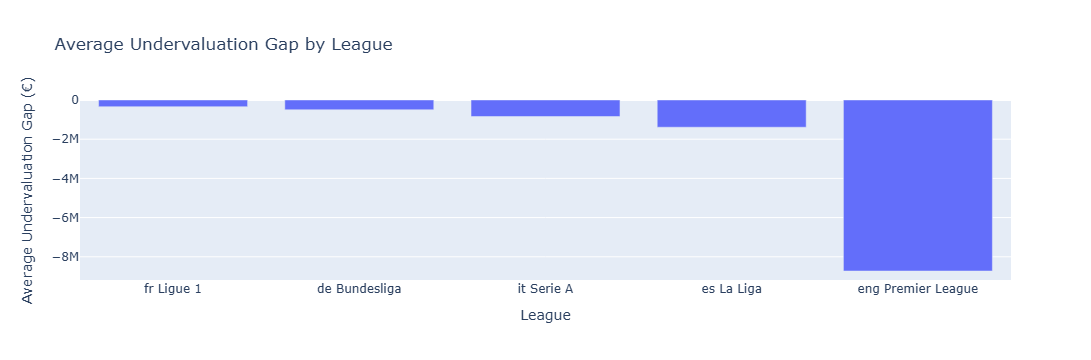

In [31]:
# Visual 7 — League Breakdown

df_filtered = df_filtered.copy()

# Find league dummy columns created from one-hot encoding
league_cols = [col for col in df_filtered.columns if col.startswith("Comp_")]

if len(league_cols) > 0:

    # Convert dummy columns to numeric to avoid bool/string comparison errors
    df_filtered[league_cols] = df_filtered[league_cols].apply(
        pd.to_numeric,
        errors="coerce"
    ).fillna(0)

    # Recreate league name from one-hot encoded columns
    df_filtered["League"] = df_filtered[league_cols].idxmax(axis=1)
    df_filtered["League"] = df_filtered["League"].str.replace("Comp_", "", regex=False)

    # Summarise by league
    league_summary = (
        df_filtered
        .groupby("League")
        .agg(
            avg_actual_value=("actual_value", "mean"),
            avg_predicted_value=("predicted_value", "mean"),
            avg_undervaluation_gap=("undervaluation_gap", "mean"),
            player_count=("Player", "count")
        )
        .reset_index()
        .sort_values("avg_undervaluation_gap", ascending=False)
    )

    display(league_summary)

    # Plot league comparison
    fig = px.bar(
        league_summary,
        x="League",
        y="avg_undervaluation_gap",
        hover_data=[
            "avg_actual_value",
            "avg_predicted_value",
            "player_count"
        ],
        title="Average Undervaluation Gap by League",
        labels={
            "League": "League",
            "avg_undervaluation_gap": "Average Undervaluation Gap (€)"
        }
    )

    fig.show()

else:
    print("No league dummy columns found.")

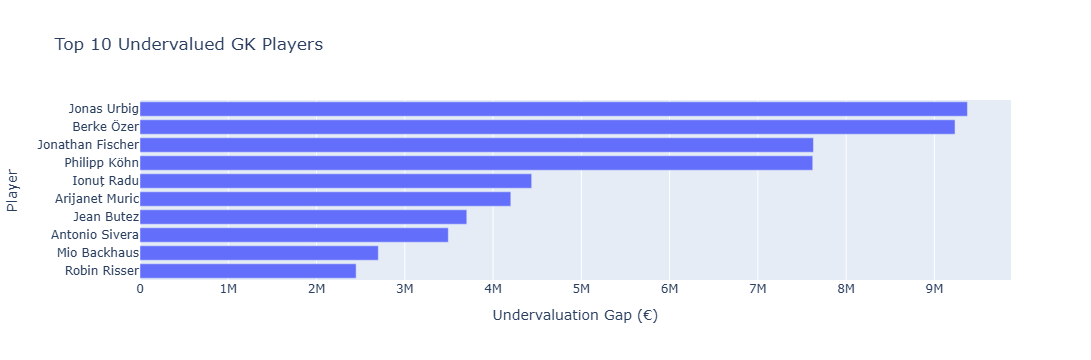

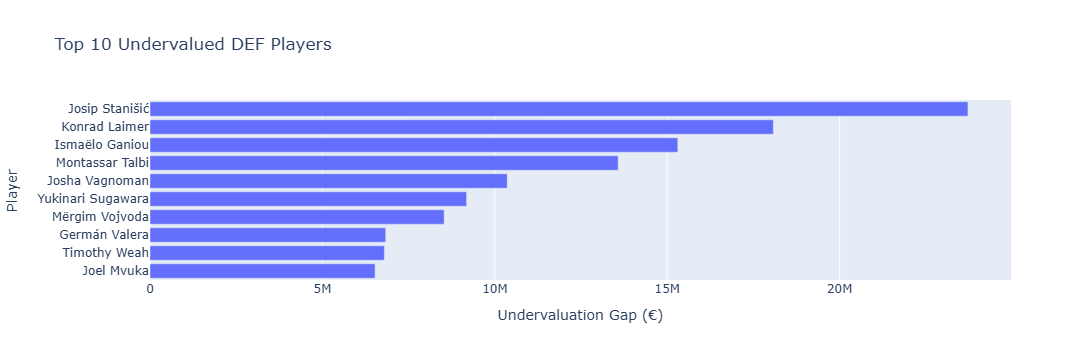

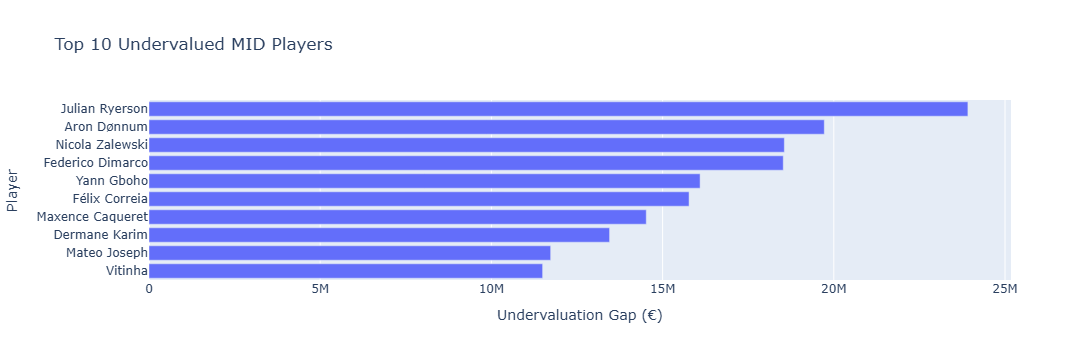

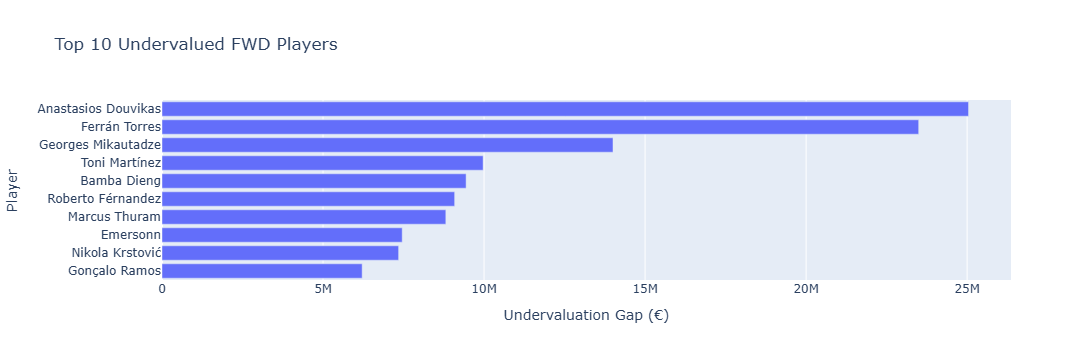

In [16]:
# Visual 8 — Top 10 undervalued players per position

positions = ["GK", "DEF", "MID", "FWD"]

for pos in positions:
    
    pos_df = df_filtered[df_filtered["position_group"] == pos]
    
    top_pos = pos_df.sort_values(
        "undervaluation_gap",
        ascending=False
    ).head(10)

    fig = px.bar(
        top_pos.sort_values("undervaluation_gap"),
        x="undervaluation_gap",
        y="Player",
        orientation="h",
        title=f"Top 10 Undervalued {pos} Players",
        labels={
            "undervaluation_gap": "Undervaluation Gap (€)",
            "Player": "Player"
        },
        hover_data=["actual_value", "predicted_value"]
    )

    fig.show()

In [32]:
# Clean league columns
league_cols = [col for col in df_filtered.columns if col.startswith("Comp_")]

df_filtered[league_cols] = df_filtered[league_cols].apply(
    pd.to_numeric, errors="coerce"
).fillna(0)

df_filtered["League"] = df_filtered[league_cols].idxmax(axis=1)
df_filtered["League"] = df_filtered["League"].str.replace("Comp_", "", regex=False)

# KEEP ONLY REAL LEAGUES
valid_leagues = [
    "eng Premier League",
    "es La Liga",
    "it Serie A",
    "de Bundesliga",
    "fr Ligue 1"
]

df_filtered = df_filtered[df_filtered["League"].isin(valid_leagues)].copy()

print("Leagues after cleaning:", df_filtered["League"].unique())

Leagues after cleaning: <ArrowStringArray>
['eng Premier League', 'es La Liga', 'fr Ligue 1', 'it Serie A',
 'de Bundesliga']
Length: 5, dtype: str


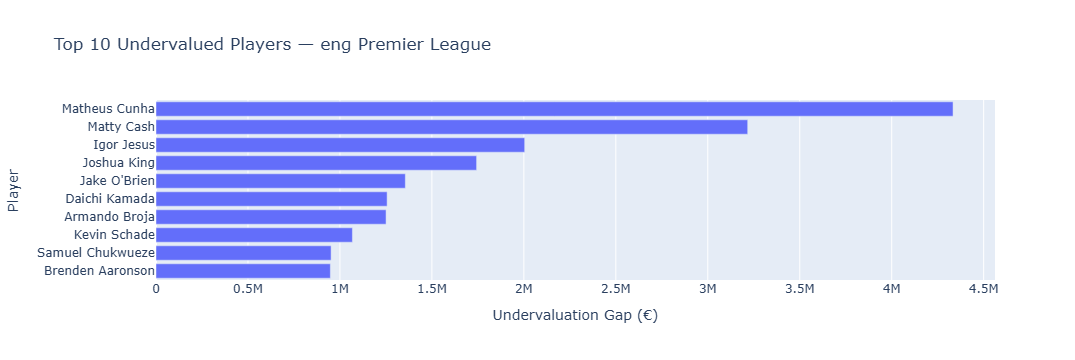

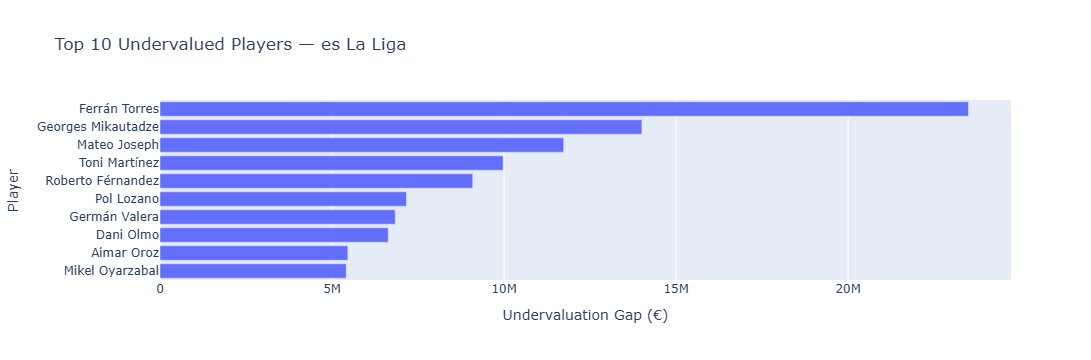

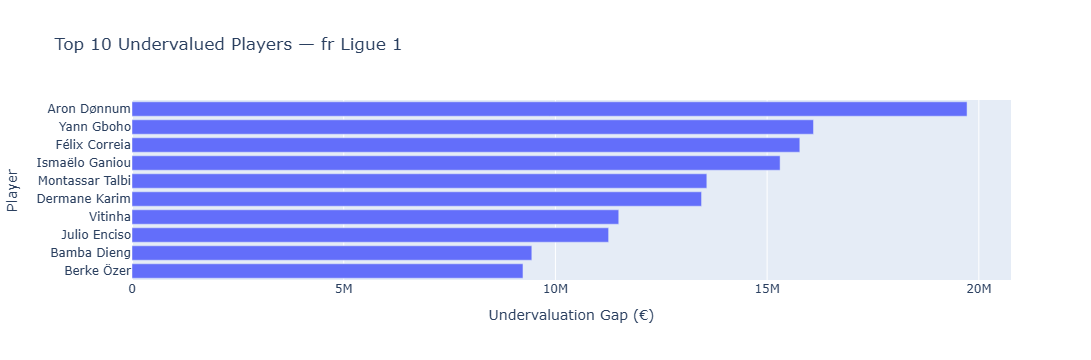

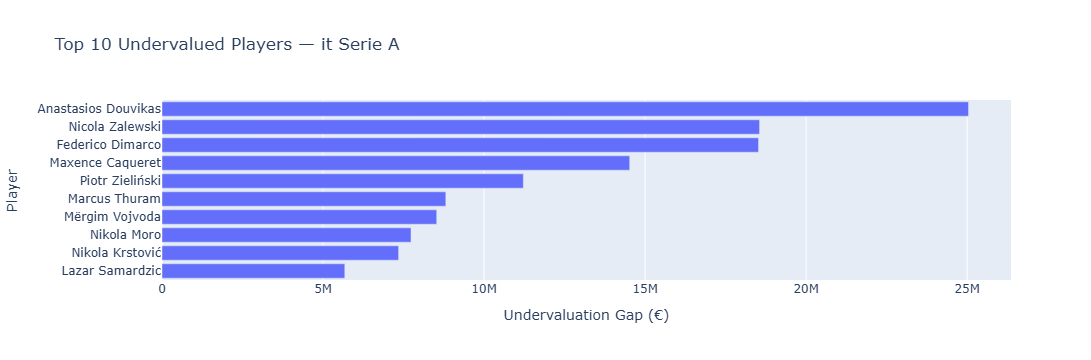

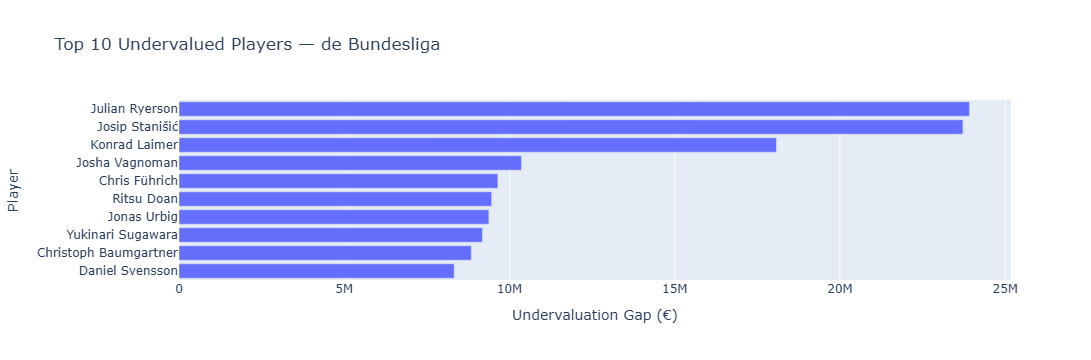

In [33]:
# Visual 9 — Top 10 undervalued players per league

leagues = df_filtered["League"].unique()

for league in leagues:
    
    league_df = df_filtered[df_filtered["League"] == league]
    
    top_league = league_df.sort_values(
        "undervaluation_gap",
        ascending=False
    ).head(10)

    fig = px.bar(
        top_league.sort_values("undervaluation_gap"),
        x="undervaluation_gap",
        y="Player",
        orientation="h",
        title=f"Top 10 Undervalued Players — {league}",
        labels={
            "undervaluation_gap": "Undervaluation Gap (€)",
            "Player": "Player"
        },
        hover_data=["actual_value", "predicted_value"]
    )

    fig.show()

In [34]:
recommendation_table = top_gap[[
    "Player",
    "actual_value",
    "predicted_value",
    "undervaluation_gap",
    "undervaluation_pct"
]].head(10).copy()

recommendation_table["actual_value"] = recommendation_table["actual_value"].round(0)
recommendation_table["predicted_value"] = recommendation_table["predicted_value"].round(0)
recommendation_table["undervaluation_gap"] = recommendation_table["undervaluation_gap"].round(0)
recommendation_table["undervaluation_pct"] = (recommendation_table["undervaluation_pct"] * 100).round(1)

recommendation_table

,Player,actual_value,predicted_value,undervaluation_gap,undervaluation_pct
0,Anastasios Douvikas,18000000,43043825.0,25043825.0,139.1
1,Julian Ryerson,25000000,48916094.0,23916094.0,95.7
2,Josip Stanišić,35000000,58720209.0,23720209.0,67.8
3,Ferrán Torres,50000000,73495492.0,23495492.0,47.0
4,Aron Dønnum,5000000,24721953.0,19721953.0,394.4
5,Nicola Zalewski,20000000,38555063.0,18555063.0,92.8
6,Federico Dimarco,50000000,68523350.0,18523350.0,37.0
7,Konrad Laimer,32000000,50076439.0,18076439.0,56.5
8,Yann Gboho,15000000,31095034.0,16095034.0,107.3
9,Félix Correia,10000000,25772477.0,15772477.0,157.7


In [35]:
recommendation_table.to_csv("../data/final_top_10_recommendations.csv", index=False)

print("Final recommendation table saved.")

Final recommendation table saved.


In [ ]:
## Final Insights

The visual analysis suggests that the model can identify players whose performance profile appears stronger than their current market value.

The most useful output is not the exact predicted value, but the ranking of players with large positive gaps between predicted and actual value.

These results should be interpreted as scouting-support signals rather than definitive transfer recommendations. Wider context such as contract length, injury history, tactical fit, reputation, and transfer demand would be needed before making real recruitment decisions.